In [1]:
import subprocess
from pathlib import Path

def generate_requirements_txt(file_path="requirements.txt"):
    # Get the list of installed packages and their versions
    installed_packages = subprocess.check_output(["pip", "freeze"]).decode("utf-8").split("\n")

    # Write the packages to requirements.txt
    with open(file_path, "w") as requirements_file:
        for package in installed_packages:
            requirements_file.write(f"{package}\n")

    print(f"Requirements written to {file_path}")

# Example usage
#generate_requirements_txt()

In [2]:
import findspark
findspark.init()
findspark.find()

'/opt/anaconda3/envs/analytics/lib/python3.10/site-packages/pyspark'

In [3]:
from pyspark.sql import SparkSession
import os
os.environ['PYSPARK_SUBMIT_ARGS'] = '--packages com.datastax.spark:spark-cassandra-connector_2.12:3.2.0 \
                                                pyspark-shell'

scala_version = '2.12'  # TODO: Ensure this is correct
spark_version = '3.2.1'#'3.4.0'
packages = [
    'com.datastax.spark:spark-cassandra-connector_2.12:3.2.0'
]

 # "172.19.0.3" ip from Cassandra container
spark = SparkSession.builder\
   .master("local")\
   .appName("cassandra-test")\
    .config("spark.cassandra.connection.host", "127.0.0.1") \
    .config("spark.cassandra.auth.username", "cassandra") \
    .config("spark.cassandra.auth.password", "cassandra") \
    .config("spark.sql.extensions", "com.datastax.spark.connector.CassandraSparkExtensions") \
   .getOrCreate()
spark

:: loading settings :: url = jar:file:/opt/anaconda3/envs/analytics/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/diegogallovalenzuela/.ivy2/cache
The jars for the packages stored in: /Users/diegogallovalenzuela/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-099091fa-5461-4b90-8352-6a4c7104ab59;1.0
	confs: [default]
	found com.datastax.spark#spark-cassandra-connector_2.12;3.2.0 in central
	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.2.0 in central
	found com.datastax.oss#java-driver-core-shaded;4.13.0 in central
	found com.datastax.oss#native-protocol;1.5.0 in central
	found com.datastax.oss#java-driver-shaded-guava;25.1-jre-graal-sub-1 in central
	found com.typesafe#config;1.4.1 in central
	found org.slf4j#slf4j-api;1.7.26 in central
	found io.dropwizard.metrics#metrics-core;4.1.18 in central
	found org.hdrhistogram#HdrHistogram;2.1.12 in central
	found org.reactivestreams#reactive-streams;1.0.3 in local-m2-cache
	found com.github.stephenc.jci

In [4]:
from pyspark.sql.functions import avg, when
from pyspark.sql.types import StructType, StructField, StringType, LongType, DoubleType
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.functions import from_unixtime, col
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, hour, dayofmonth

In [5]:
# Define the custom schema for your Cassandra table
custom_schema = StructType([
    StructField("book", StringType(), True),
    StructField("i", LongType(), True),
    StructField("a", DoubleType(), True),
    StructField("r", DoubleType(), True),
    StructField("v", DoubleType(), True),
    StructField("morder", StringType(), True),
    StructField("torder", StringType(), True),
    StructField("t", LongType(), True),
    StructField("x", LongType(), True)
])

In [6]:
df = spark.read.format("org.apache.spark.sql.cassandra") \
    .options(table="trades", keyspace="crypto_trading") \
    .load()
# Use the count method to get the total number of records
total_records = df.count()

# Print the total number of records
print("Total Number of Records:", total_records)

df.show()

23/12/28 13:55:47 WARN PlainTextAuthProviderBase: [] /127.0.0.1:9042 did not send an authentication challenge; This is suspicious because the driver expects authentication
23/12/28 13:55:48 WARN PlainTextAuthProviderBase: [] /127.0.0.1:9042 did not send an authentication challenge; This is suspicious because the driver expects authentication
23/12/28 13:55:48 WARN PlainTextAuthProviderBase: [] /127.0.0.1:9042 did not send an authentication challenge; This is suspicious because the driver expects authentication
23/12/28 13:55:48 WARN PlainTextAuthProviderBase: [] /127.0.0.1:9042 did not send an authentication challenge; This is suspicious because the driver expects authentication
23/12/28 13:55:56 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


Total Number of Records: 1098


23/12/28 13:56:24 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---------+----------+-------+----------------+--------+---+----------------+-------------+-------------+
|        i|         a|   book|          morder|       r|  t|          torder|            v|            x|
+---------+----------+-------+----------------+--------+---+----------------+-------------+-------------+
|103659702|0.17844709|btc_mxn|JMmfWFxLalSd6Uhu|493750.0|  0|HBklKg8nZsqBxzqg|88108.2506875|1696271232825|
|103656122|0.02124474|btc_mxn|XdGS31k9IafGsczv|494240.0|  1|kzDkl5Mjjh4AZzZ5|10500.0027344|1696268747803|
|103723188| 1.0239E-4|btc_mxn|GaZBOiULsr7ATfiq|488320.0|  1|ZNiRZNGkZz2zYRiU|         50.0|1696349484849|
|103724146| 0.0198011|btc_mxn|yHjQEnsh2CEJdzl5|488230.0|  0|NTQlkY24ZmmxNZTh|  9667.491053|1696350167051|
|103659839| 4.0481E-4|btc_mxn|BduXceLl9sNFas1p|494060.0|  1|JzI0OxwRN1mFMMY0|        200.0|1696271360219|
|103870536|0.01823669|btc_mxn|qa8PGo6VhCSrNEA6|500240.0|  0|3BP7tU48Fx6UEBim| 9122.7218056|1696522181635|
|103937656|0.02139852|btc_mxn|KdvKwHyYhwy2iygg

In [7]:
# Group by "t" and "x" columns and aggregate by calculating the average of other columns
result_df = df.groupBy("t", "x", "i").agg(
    avg("a").alias("avg_a"),
    avg("r").alias("avg_r"),
    avg("v").alias("avg_v")
)

# Show the resulting DataFrame
result_df.show()


23/12/28 13:56:27 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---+-------------+---------+----------+--------+-------------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|
+---+-------------+---------+----------+--------+-------------+
|  0|1696611355640|103943043| 1.2086E-4|506980.0|   61.2736028|
|  0|1696350789159|103724785|  0.065874|488540.0|  32182.08396|
|  0|1696522124518|103870458|0.02287854|500250.0| 11444.989635|
|  1|1696610696169|103942234|0.00196932|507790.0|       1000.0|
|  0|1696350822055|103724817|    1.5E-5|488480.0|       7.3272|
|  0|1696349962022|103723894|    0.0032|488030.0|     1561.696|
|  0|1696348214939|103721324|  0.002132|488350.0|    1041.1622|
|  1|1696608486908|103939295| 9.8361E-4|508330.0|        500.0|
|  0|1696272240641|103661390|     0.001|490640.0|       490.64|
|  0|1696606809163|103936714| 0.2239392|505420.0|113183.350464|
|  0|1696272475648|103661726|0.03729692|490650.0| 18299.733798|
|  0|1696609886018|103941209|  4.806E-5|506470.0|   24.3409482|
|  0|1696269529544|103657262|  4.464E-4|

In [8]:
def search_by_timestamp(df, x_value):
    result = df.filter(df["x"] == x_value)
    return result

def search_by_order_type_id(df, otid, otype="morder"):
    result = df.filter(df[otype] == otid)
    return result

def search_by_transaction_id(df, tid):
    result = df.filter(df["i"] == tid)
    return result

In [9]:
# Assuming you have defined your result_df DataFrame
specific_x_value = 1696612691334
specify_df = result_df
search_result_1 = search_by_timestamp(result_df, specific_x_value)

specify_df = df
search_result_2 = search_by_timestamp(df, specific_x_value)

# Show the search result DataFrame
search_result_1.show()
search_result_2.show()

otid = "4zHFxdQv4CO9W2zj"
tid = 103944664
otype = "morder"

search_result_3 = search_by_order_type_id(specify_df, otid, otype)
search_result_4 = search_by_transaction_id(specify_df, tid)

# Show the search result DataFrame
print(f"Results filtered by their {otype} type id")
search_result_3.show()
print("Results filtered by unique transaction id 'i'")
search_result_4.show()

23/12/28 13:56:34 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---+-------------+---------+---------+--------+-----------+
|  t|            x|        i|    avg_a|   avg_r|      avg_v|
+---+-------------+---------+---------+--------+-----------+
|  0|1696612691334|103944664|0.0035569|505720.0|1798.795468|
+---+-------------+---------+---------+--------+-----------+



23/12/28 13:56:37 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---------+---------+-------+----------------+--------+---+----------------+-----------+-------------+
|        i|        a|   book|          morder|       r|  t|          torder|          v|            x|
+---------+---------+-------+----------------+--------+---+----------------+-----------+-------------+
|103944664|0.0035569|btc_mxn|4zHFxdQv4CO9W2zj|505720.0|  0|xhaoXtKtmkL9Lir8|1798.795468|1696612691334|
+---------+---------+-------+----------------+--------+---+----------------+-----------+-------------+

Results filtered by their morder type id


23/12/28 13:56:38 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---------+----------+-------+----------------+--------+---+----------------+-----------+-------------+
|        i|         a|   book|          morder|       r|  t|          torder|          v|            x|
+---------+----------+-------+----------------+--------+---+----------------+-----------+-------------+
|103944644|0.00160609|btc_mxn|4zHFxdQv4CO9W2zj|505720.0|  0|hNTUMYmMUO5xMchZ|812.2318348|1696612673945|
|103944652|    0.0031|btc_mxn|4zHFxdQv4CO9W2zj|505720.0|  0|jxTxQ2QMOZ2YmmYN|   1567.732|1696612680161|
|103944643| 1.5578E-4|btc_mxn|4zHFxdQv4CO9W2zj|505720.0|  0|jWZMzcmwGRjYTmRk| 78.7810616|1696612672616|
|103944664| 0.0035569|btc_mxn|4zHFxdQv4CO9W2zj|505720.0|  0|xhaoXtKtmkL9Lir8|1798.795468|1696612691334|
+---------+----------+-------+----------------+--------+---+----------------+-----------+-------------+

Results filtered by unique transaction id 'i'


23/12/28 13:56:39 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---------+---------+-------+----------------+--------+---+----------------+-----------+-------------+
|        i|        a|   book|          morder|       r|  t|          torder|          v|            x|
+---------+---------+-------+----------------+--------+---+----------------+-----------+-------------+
|103944664|0.0035569|btc_mxn|4zHFxdQv4CO9W2zj|505720.0|  0|xhaoXtKtmkL9Lir8|1798.795468|1696612691334|
+---------+---------+-------+----------------+--------+---+----------------+-----------+-------------+



In [10]:
# Use the count method to get the total number of records
total_records = result_df.count()

# Print the total number of records
print("Total Number of Records:", total_records)

23/12/28 13:56:40 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


Total Number of Records: 1098


In [11]:
# Create two separate DataFrames for "t" equals 0 and "t" equals 1
grouped_buy_df = result_df.filter(result_df["t"] == 0)
grouped_sell_df = result_df.filter(result_df["t"] == 1)

In [12]:
# Show the resulting DataFrames
grouped_buy_df.show()

# Use the count method to get the total number of records
total_buy_records = grouped_buy_df.count()

# Print the total number of records
print("Total Number of Buy Records:", total_buy_records)

23/12/28 13:56:44 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---+-------------+---------+----------+--------+-------------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|
+---+-------------+---------+----------+--------+-------------+
|  0|1696611355640|103943043| 1.2086E-4|506980.0|   61.2736028|
|  0|1696350789159|103724785|  0.065874|488540.0|  32182.08396|
|  0|1696522124518|103870458|0.02287854|500250.0| 11444.989635|
|  0|1696350822055|103724817|    1.5E-5|488480.0|       7.3272|
|  0|1696349962022|103723894|    0.0032|488030.0|     1561.696|
|  0|1696348214939|103721324|  0.002132|488350.0|    1041.1622|
|  0|1696272240641|103661390|     0.001|490640.0|       490.64|
|  0|1696606809163|103936714| 0.2239392|505420.0|113183.350464|
|  0|1696272475648|103661726|0.03729692|490650.0| 18299.733798|
|  0|1696609886018|103941209|  4.806E-5|506470.0|   24.3409482|
|  0|1696269529544|103657262|  4.464E-4|494030.0|   220.534992|
|  0|1696354115337|103728282|     0.033|490390.0|     16182.87|
|  0|1696606092072|103935661|0.01935339|

23/12/28 13:56:47 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


Total Number of Buy Records: 685


In [13]:
# Show the resulting DataFrames
grouped_sell_df.show()

# Use the count method to get the total number of records
total_sell_records = grouped_sell_df.count()

# Print the total number of records
print("Total Number of Sell Records:", total_sell_records)

23/12/28 13:56:50 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---+-------------+---------+----------+--------+-------------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|
+---+-------------+---------+----------+--------+-------------+
|  1|1696610696169|103942234|0.00196932|507790.0|       1000.0|
|  1|1696608486908|103939295| 9.8361E-4|508330.0|        500.0|
|  1|1696613095108|103945148|0.00168696|506390.0|  854.2596744|
|  1|1696350238170|103724227|0.00486228|488900.0|  2377.168692|
|  1|1696271856382|103660332| 8.0808E-4|495000.0|        400.0|
|  1|1696269762919|103657774|  1.487E-4|494730.0|    73.566351|
|  1|1696348368923|103721577|0.00102444|488070.0|        500.0|
|  1|1696349805811|103723596|   9.61E-5|489060.0|         47.0|
|  1|1696607391315|103937489| 2.0483E-4|507100.0|   103.869293|
|  1|1696607376955|103937459|    0.0072|506900.0|      3649.68|
|  1|1696271764822|103660205|0.00950282|494590.0|       4700.0|
|  1|1696352256442|103726360|0.00102022|490090.0|  499.9996198|
|  1|1696353905330|103728069|  5.098E-5|

23/12/28 13:56:54 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


Total Number of Sell Records: 413


In [14]:
def convert_x_to_date_with_timestamp(df):
    # Assuming "x" represents timestamp in milliseconds
    df = df.withColumn("timestamp", (col("x") / 1000).cast("timestamp"))
    return df.select("t", "x", "i", "avg_a", "avg_r", "avg_v", "timestamp")

In [15]:
# Convert "x" column to date type for grouped_buy_df and grouped_sell_df
grouped_buy_df = convert_x_to_date_with_timestamp(grouped_buy_df)
df_grouped_buy_desc = grouped_buy_df.orderBy(F.desc("timestamp"))
print("Buy dataframe object with Timestamp sorted in DESC order")
df_grouped_buy_desc.show()


grouped_sell_df = convert_x_to_date_with_timestamp(grouped_sell_df)
df_grouped_sell_desc = grouped_sell_df.orderBy(F.desc("timestamp"))
print("Sell dataframe object with Timestamp sorted in DESC order")
grouped_sell_df.show()


Buy dataframe object with Timestamp sorted in DESC order


23/12/28 13:57:01 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---+-------------+---------+----------+--------+------------+--------------------+
|  t|            x|        i|     avg_a|   avg_r|       avg_v|           timestamp|
+---+-------------+---------+----------+--------+------------+--------------------+
|  0|1696721987410|104016477| 1.0009E-4|507010.0|  50.7466309|2023-10-07 18:39:...|
|  0|1696721986178|104016476|  9.705E-4|507190.0|  492.227895|2023-10-07 18:39:...|
|  0|1696721973661|104016475|  0.072389|507190.0| 36714.97691|2023-10-07 18:39:...|
|  0|1696721946976|104016455| 1.7405E-4|506970.0|  88.2381285|2023-10-07 18:39:...|
|  0|1696721887809|104016426|0.00200172|507180.0|1015.2323496|2023-10-07 18:38:...|
|  0|1696721864933|104016412|     0.009|507180.0|     4564.62|2023-10-07 18:37:...|
|  0|1696721857204|104016408| 5.9682E-4|507190.0| 302.7011358|2023-10-07 18:37:...|
|  0|1696721764085|104016360|0.00323312|507130.0|1639.6121456|2023-10-07 18:36:...|
|  0|1696721723852|104016331|0.00159274|507090.0| 807.6625266|2023-10-07 18:

23/12/28 13:57:06 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---+-------------+---------+----------+--------+-------------+--------------------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|           timestamp|
+---+-------------+---------+----------+--------+-------------+--------------------+
|  1|1696610696169|103942234|0.00196932|507790.0|       1000.0|2023-10-06 11:44:...|
|  1|1696608486908|103939295| 9.8361E-4|508330.0|        500.0|2023-10-06 11:08:...|
|  1|1696613095108|103945148|0.00168696|506390.0|  854.2596744|2023-10-06 12:24:...|
|  1|1696350238170|103724227|0.00486228|488900.0|  2377.168692|2023-10-03 11:23:...|
|  1|1696271856382|103660332| 8.0808E-4|495000.0|        400.0|2023-10-02 13:37:...|
|  1|1696269762919|103657774|  1.487E-4|494730.0|    73.566351|2023-10-02 13:02:...|
|  1|1696348368923|103721577|0.00102444|488070.0|        500.0|2023-10-03 10:52:...|
|  1|1696349805811|103723596|   9.61E-5|489060.0|         47.0|2023-10-03 11:16:...|
|  1|1696607391315|103937489| 2.0483E-4|507100.0|   103.869293|20

In [16]:
def plot_dataframe(df, title):
    # Assuming you have columns "x" and "avg_v" for the x and y axes
    x = df.select("avg_a").collect()
    y = df.select("avg_v").collect()

    plt.figure(figsize=(12, 6))
    plt.scatter(x, y, label="avg_v", s=30, alpha=0.5)  # No line style specified
    #plt.scatter(x, y, label="avg_v", marker='o', s=30, alpha=0.5)  # 'o' marker for points
    plt.xlabel("avg_a")
    plt.ylabel("avg_v")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_multiple_columns(dataframes, titles, date_range_day=None, date_range_hour=None):
    # Assuming you have columns "timestamp", "avg_a", "avg_r", and "avg_v"
    columns_to_plot = ["avg_a", "avg_r", "avg_v"]

    for col_to_plot in columns_to_plot:
        plt.figure(figsize=(12, 6))

        for df, title in zip(dataframes, titles):
            filtered_df = filter_dataframe_by_date(df, date_range_day, date_range_hour)
            x = filtered_df.select("timestamp").collect()
            y = filtered_df.select(col_to_plot).collect()
            plt.scatter(x, y, label=f"{title} - {col_to_plot}", s=30, alpha=0.5)

        plt.xlabel("Timestamp")
        plt.ylabel(col_to_plot)
        plt.title(f"Combined Scatter Plot for {col_to_plot}")
        plt.legend()
        plt.grid(True)
        plt.show()

def filter_dataframe_by_date(df, date_range_day, date_range_hour):
    filtered_df = df

    if date_range_day:
        filtered_df = filtered_df.filter(dayofmonth("timestamp").between(*date_range_day))

    if date_range_hour:
        filtered_df = filtered_df.filter(hour("timestamp").between(*date_range_hour))

    return filtered_df

23/12/28 13:57:10 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:14 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


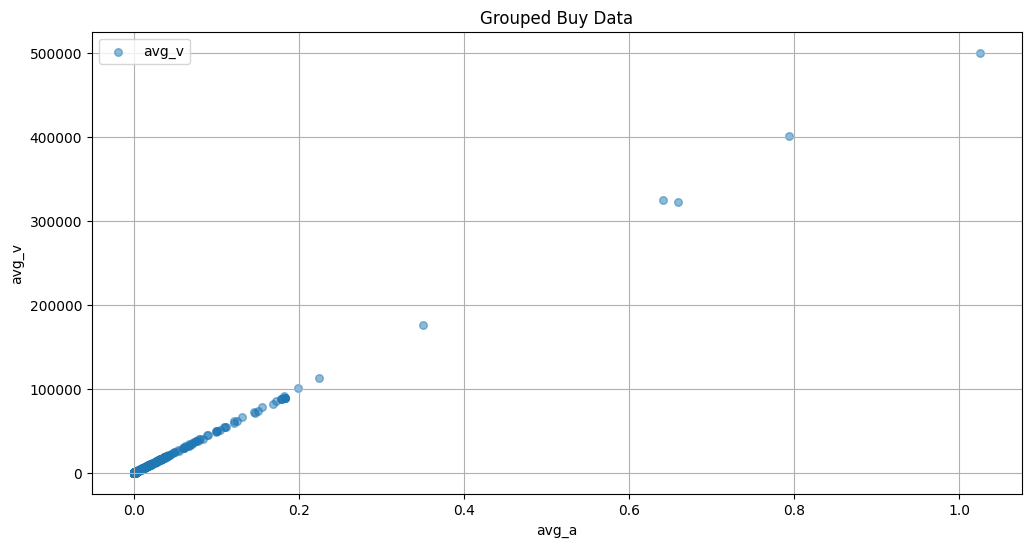

23/12/28 13:57:18 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:20 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


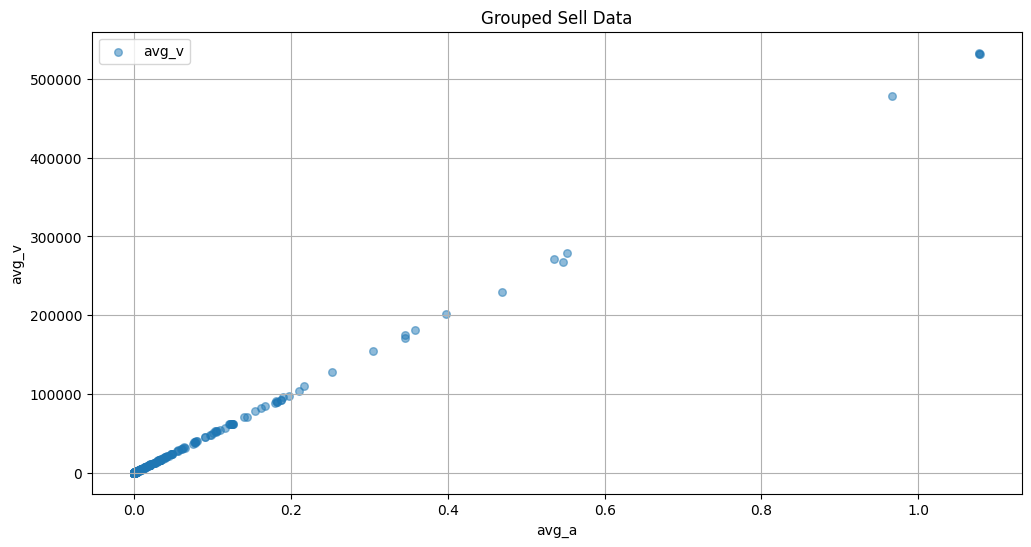

In [17]:
# Plot the DataFrames
plot_dataframe(grouped_buy_df, "Grouped Buy Data")
plot_dataframe(grouped_sell_df, "Grouped Sell Data")


23/12/28 13:57:22 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:25 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:28 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:30 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


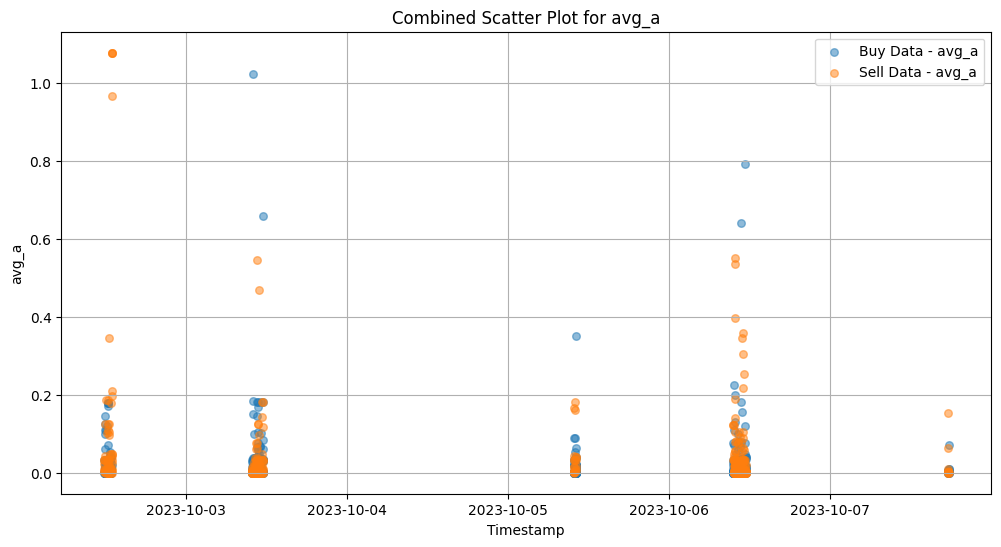

23/12/28 13:57:34 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:35 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:38 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:39 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


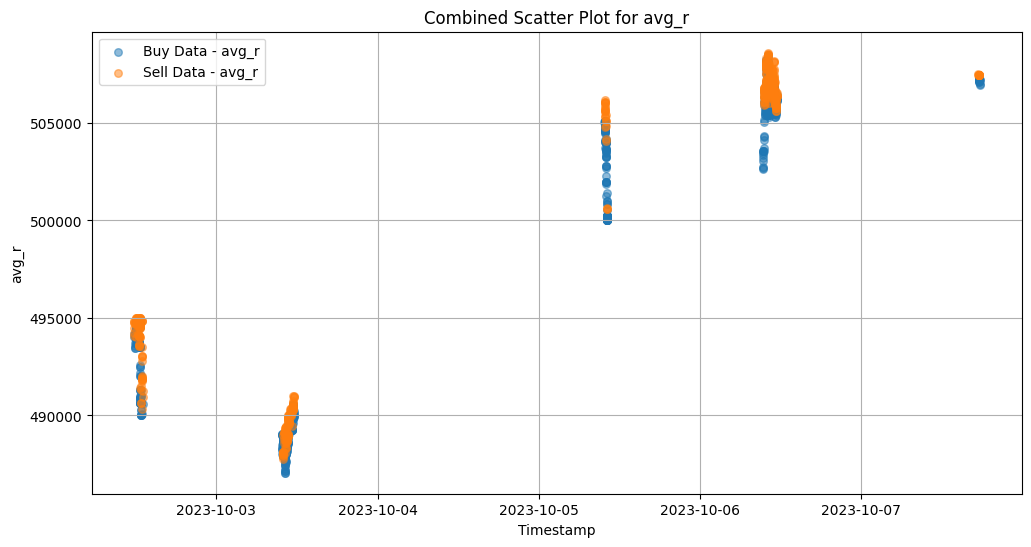

23/12/28 13:57:43 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:45 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:47 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:49 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


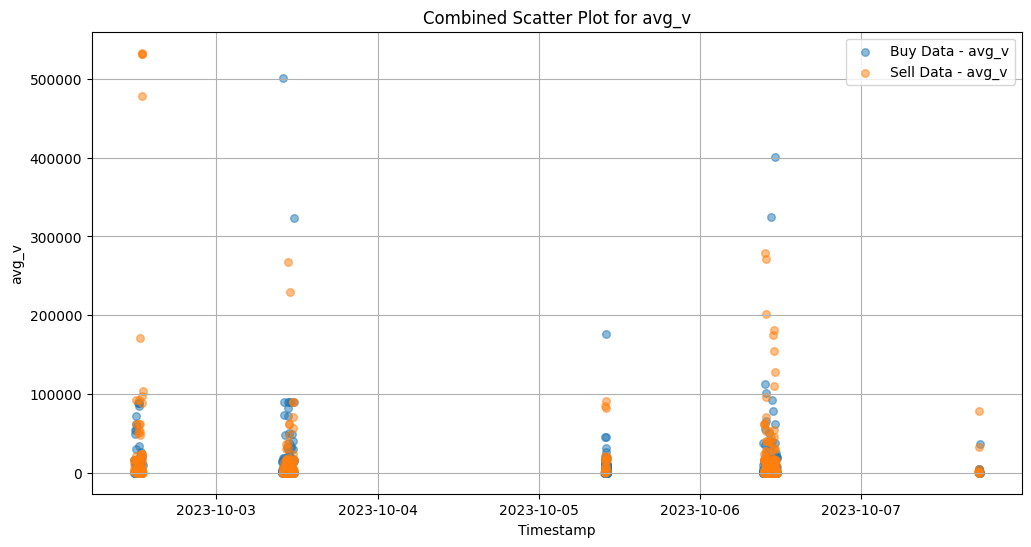

In [18]:
dataframes = [df_grouped_buy_desc, df_grouped_sell_desc]
titles = ["Buy Data", "Sell Data"]

# Plot three charts for "avg_a," "avg_r," and "avg_v"
# Default settings (no date range filtering)
plot_multiple_columns(dataframes, titles)

# Specify date range by day (e.g., from day 2 to day 5)
#plot_multiple_columns(dataframes, titles, date_range_day=(2, 5))

# Specify date range by hour (e.g., from hour 8 to hour 16)
#plot_multiple_columns(dataframes, titles, date_range_hour=(8, 16))

23/12/28 13:57:51 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:52 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:53 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:54 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


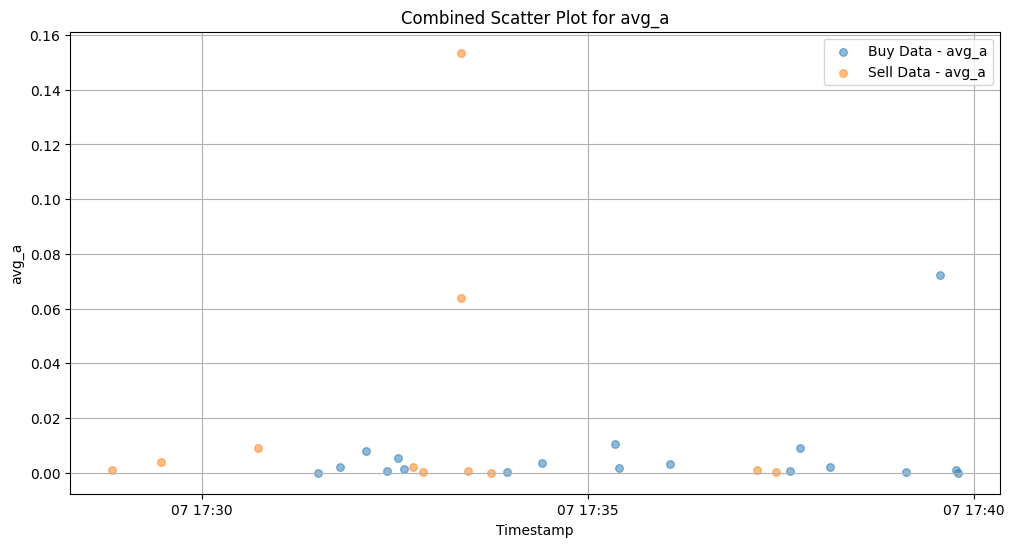

23/12/28 13:57:56 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:57 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:58 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:57:59 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


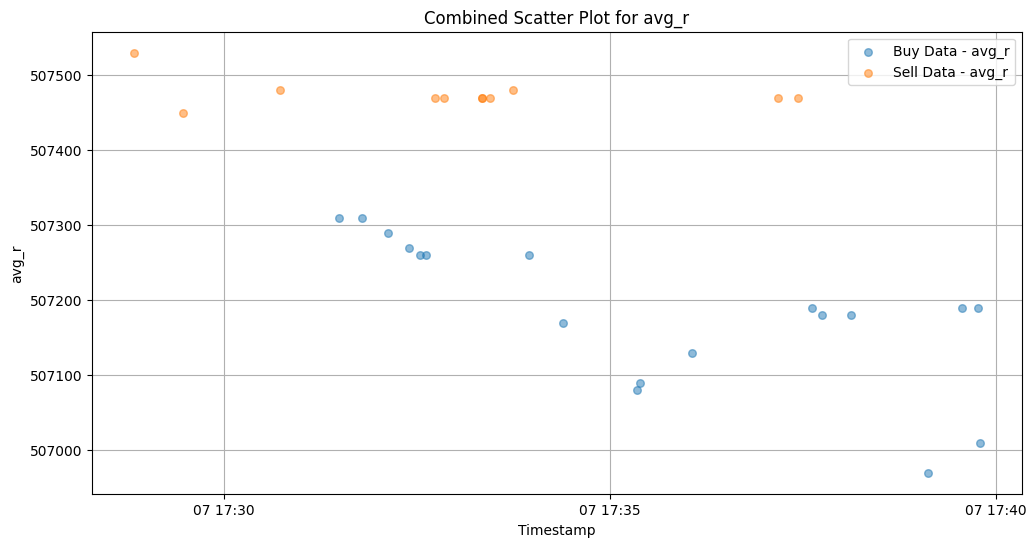

23/12/28 13:58:00 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:01 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:02 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:02 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


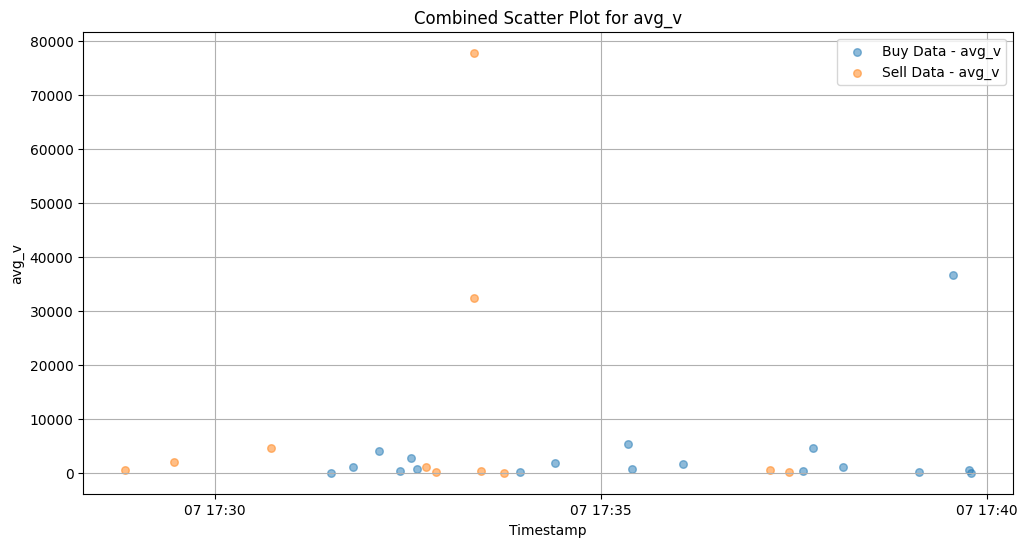

In [19]:
# Specify both date range by day and hour
plot_multiple_columns(dataframes, titles, date_range_day=(7, 7), date_range_hour=(8, 24))

In [20]:
def calculate_sma(df, column_name, window_size=7):
    window_spec = Window().orderBy("timestamp").rowsBetween(-window_size, 0)
    sma_column_name = f"{column_name}_sma{window_size}"

    df_with_sma = df.withColumn(sma_column_name, F.avg(column_name).over(window_spec))
    
    return df_with_sma

In [21]:
# Calculating Simple Moving Average (SMA) for buy df with columns like "timestamp," "avg_a," "avg_r," and "avg_v"
buy_with_avg_a_sma = calculate_sma(grouped_buy_df, "avg_a")
buy_with_avg_r_sma = calculate_sma(grouped_buy_df, "avg_r")
buy_with_avg_v_sma = calculate_sma(grouped_buy_df, "avg_v")

print("Bid SMA Average amount")
buy_with_avg_a_sma.show()
print("Bid SMA Average rate")
buy_with_avg_r_sma.show()
print("Bid SMA Average value")
buy_with_avg_v_sma.show()

# Calculating Simple Moving Average (SMA) for sell df with columns like "timestamp," "avg_a," "avg_r," and "avg_v"
sell_with_avg_a_sma = calculate_sma(grouped_sell_df, "avg_a")
sell_with_avg_r_sma = calculate_sma(grouped_sell_df, "avg_r")
sell_with_avg_v_sma = calculate_sma(grouped_sell_df, "avg_v")

print("Ask SMA Average amount")
sell_with_avg_a_sma.show()
print("Ask SMA Average rate")
sell_with_avg_r_sma.show()
print("Ask SMA Average value")
sell_with_avg_v_sma.show()

Bid SMA Average amount


23/12/28 13:58:04 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 1

+---+-------------+---------+----------+--------+-------------+--------------------+--------------------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|           timestamp|          avg_a_sma7|
+---+-------------+---------+----------+--------+-------------+--------------------+--------------------+
|  0|1696268865552|103656211|0.03288765|494200.0|  16253.07663|2023-10-02 12:47:...|          0.03288765|
|  0|1696268893913|103656248|  3.977E-4|494030.0|   196.475731|2023-10-02 12:48:...|         0.016642675|
|  0|1696269169064|103656631| 0.0024691|494220.0|  1220.278602|2023-10-02 12:52:...|          0.01191815|
|  0|1696269274576|103656850|  1.074E-4|493550.0|     53.00727|2023-10-02 12:54:...|        0.0089654625|
|  0|1696269391943|103656987|0.01960426|493480.0| 9674.3102248|2023-10-02 12:56:...|         0.011093222|
|  0|1696269418390|103657030|0.02698166|494160.0|13333.2571056|2023-10-02 12:56:...|         0.013741295|
|  0|1696269434338|103657058|       0.1|494060

23/12/28 13:58:07 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:07 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 1

+---+-------------+---------+----------+--------+-------------+--------------------+------------------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|           timestamp|        avg_r_sma7|
+---+-------------+---------+----------+--------+-------------+--------------------+------------------+
|  0|1696268865552|103656211|0.03288765|494200.0|  16253.07663|2023-10-02 12:47:...|          494200.0|
|  0|1696268893913|103656248|  3.977E-4|494030.0|   196.475731|2023-10-02 12:48:...|          494115.0|
|  0|1696269169064|103656631| 0.0024691|494220.0|  1220.278602|2023-10-02 12:52:...|          494150.0|
|  0|1696269274576|103656850|  1.074E-4|493550.0|     53.00727|2023-10-02 12:54:...|          494000.0|
|  0|1696269391943|103656987|0.01960426|493480.0| 9674.3102248|2023-10-02 12:56:...|          493896.0|
|  0|1696269418390|103657030|0.02698166|494160.0|13333.2571056|2023-10-02 12:56:...|          493940.0|
|  0|1696269434338|103657058|       0.1|494060.0|      49406.0|2

...

23/12/28 13:58:14 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 1

+---+-------------+---------+----------+--------+-------------+--------------------+--------------------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|           timestamp|          avg_a_sma7|
+---+-------------+---------+----------+--------+-------------+--------------------+--------------------+
|  1|1696268747803|103656122|0.02124474|494240.0|10500.0027344|2023-10-02 12:45:...|          0.02124474|
|  1|1696268747803|103656121|0.00404784|494090.0| 1999.9972656|2023-10-02 12:45:...|0.012646290000000001|
|  1|1696268843830|103656183|0.00101114|494490.0|        500.0|2023-10-02 12:47:...|0.008767906666666667|
|  1|1696268864856|103656210|0.00909403|494830.0|       4500.0|2023-10-02 12:47:...|0.008849437500000001|
|  1|1696268869936|103656213|     0.033|494760.0|     16327.08|2023-10-02 12:47:...|0.013679550000000002|
|  1|1696268869937|103656214|0.03275963|494780.0|     16208.81|2023-10-02 12:47:...|0.016859563333333334|
|  1|1696269354010|103656941|0.00606379|494740

23/12/28 13:58:17 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 1

+---+-------------+---------+----------+--------+-------------+--------------------+-----------------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|           timestamp|       avg_r_sma7|
+---+-------------+---------+----------+--------+-------------+--------------------+-----------------+
|  1|1696268747803|103656122|0.02124474|494240.0|10500.0027344|2023-10-02 12:45:...|         494240.0|
|  1|1696268747803|103656121|0.00404784|494090.0| 1999.9972656|2023-10-02 12:45:...|         494165.0|
|  1|1696268843830|103656183|0.00101114|494490.0|        500.0|2023-10-02 12:47:...|494273.3333333333|
|  1|1696268864856|103656210|0.00909403|494830.0|       4500.0|2023-10-02 12:47:...|         494412.5|
|  1|1696268869936|103656213|     0.033|494760.0|     16327.08|2023-10-02 12:47:...|         494482.0|
|  1|1696268869937|103656214|0.03275963|494780.0|     16208.81|2023-10-02 12:47:...|494531.6666666667|
|  1|1696269354010|103656941|0.00606379|494740.0|       3000.0|2023-10-02

23/12/28 13:58:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [22]:
def calculate_trend(df, column_name, window_size=7):
    window_spec = Window().orderBy("timestamp").rowsBetween(-window_size, 0)
    sma_column_name = f"{column_name}_sma{window_size}"

    # Calculate the SMA
    df_with_sma = df.withColumn(sma_column_name, F.avg(column_name).over(window_spec))

    # Calculate the trend based on the SMA
    trend_column_name = f"{column_name}_trend"
    df_with_trend = df_with_sma.withColumn(trend_column_name, 
                                           F.when(F.col(column_name) > F.col(sma_column_name), 1)
                                           .when(F.col(column_name) < F.col(sma_column_name), -1)
                                           .otherwise(0))

    return df_with_trend

In [23]:
# Assuming 'df' is your DataFrame with columns like "timestamp," "avg_a," "avg_r," and "avg_v"
buy_df_with_avg_a_trend = calculate_trend(grouped_buy_df, "avg_a")
buy_df_with_avg_r_trend = calculate_trend(grouped_buy_df, "avg_r")
buy_df_with_avg_v_trend = calculate_trend(grouped_buy_df, "avg_v")

buy_df_with_avg_a_trend.show()
buy_df_with_avg_r_trend.show()
buy_df_with_avg_v_trend.show()
# Assuming 'df' is your DataFrame with columns like "timestamp," "avg_a," "avg_r," and "avg_v"
sell_df_with_avg_a_trend = calculate_trend(grouped_sell_df, "avg_a")
sell_df_with_avg_r_trend = calculate_trend(grouped_sell_df, "avg_r")
sell_df_with_avg_v_trend = calculate_trend(grouped_sell_df, "avg_v")

23/12/28 13:58:19 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:19 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 1

+---+-------------+---------+----------+--------+-------------+--------------------+--------------------+-----------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|           timestamp|          avg_a_sma7|avg_a_trend|
+---+-------------+---------+----------+--------+-------------+--------------------+--------------------+-----------+
|  0|1696268865552|103656211|0.03288765|494200.0|  16253.07663|2023-10-02 12:47:...|          0.03288765|          0|
|  0|1696268893913|103656248|  3.977E-4|494030.0|   196.475731|2023-10-02 12:48:...|         0.016642675|         -1|
|  0|1696269169064|103656631| 0.0024691|494220.0|  1220.278602|2023-10-02 12:52:...|          0.01191815|         -1|
|  0|1696269274576|103656850|  1.074E-4|493550.0|     53.00727|2023-10-02 12:54:...|        0.0089654625|         -1|
|  0|1696269391943|103656987|0.01960426|493480.0| 9674.3102248|2023-10-02 12:56:...|         0.011093222|          1|
|  0|1696269418390|103657030|0.02698166|494160.0|13333.2

23/12/28 13:58:20 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance
23/12/28 13:58:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:20 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 1

+---+-------------+---------+----------+--------+-------------+--------------------+------------------+-----------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|           timestamp|        avg_r_sma7|avg_r_trend|
+---+-------------+---------+----------+--------+-------------+--------------------+------------------+-----------+
|  0|1696268865552|103656211|0.03288765|494200.0|  16253.07663|2023-10-02 12:47:...|          494200.0|          0|
|  0|1696268893913|103656248|  3.977E-4|494030.0|   196.475731|2023-10-02 12:48:...|          494115.0|         -1|
|  0|1696269169064|103656631| 0.0024691|494220.0|  1220.278602|2023-10-02 12:52:...|          494150.0|          1|
|  0|1696269274576|103656850|  1.074E-4|493550.0|     53.00727|2023-10-02 12:54:...|          494000.0|         -1|
|  0|1696269391943|103656987|0.01960426|493480.0| 9674.3102248|2023-10-02 12:56:...|          493896.0|         -1|
|  0|1696269418390|103657030|0.02698166|494160.0|13333.2571056|2023-10-0

23/12/28 13:58:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
23/12/28 13:58:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---+-------------+---------+----------+--------+-------------+--------------------+------------------+-----------+
|  t|            x|        i|     avg_a|   avg_r|        avg_v|           timestamp|        avg_v_sma7|avg_v_trend|
+---+-------------+---------+----------+--------+-------------+--------------------+------------------+-----------+
|  0|1696268865552|103656211|0.03288765|494200.0|  16253.07663|2023-10-02 12:47:...|       16253.07663|          0|
|  0|1696268893913|103656248|  3.977E-4|494030.0|   196.475731|2023-10-02 12:48:...|      8224.7761805|         -1|
|  0|1696269169064|103656631| 0.0024691|494220.0|  1220.278602|2023-10-02 12:52:...| 5889.943654333332|         -1|
|  0|1696269274576|103656850|  1.074E-4|493550.0|     53.00727|2023-10-02 12:54:...| 4430.709558249999|         -1|
|  0|1696269391943|103656987|0.01960426|493480.0| 9674.3102248|2023-10-02 12:56:...| 5479.429691559999|          1|
|  0|1696269418390|103657030|0.02698166|494160.0|13333.2571056|2023-10-0

In [59]:
def calculate_min_max_avg_r(df, specified_date=None):
    if specified_date is None:
        # If specified_date is not provided, use the latest date in the timestamp column
        specified_date = df.select(F.max("timestamp")).first()[0]

    # Define the time window for each minute
    time_window = Window().orderBy("x").rangeBetween(-60, 0)

    # Calculate the maximum and minimum of 'avg_r' for each minute
    df_with_max_min_avg_r = df.withColumn("max_avg_r_min", F.max("avg_r").over(time_window)) \
                              .withColumn("min_avg_r_min", F.min("avg_r").over(time_window))

    # Filter the DataFrame for the specified date
    df_for_date = df_with_max_min_avg_r.filter(F.col("timestamp").cast("date") == F.lit(specified_date))

    # Drop the temporary timestamp_long column
    df_for_date = df_for_date.drop("x")
    
    return df_for_date

In [61]:
# Assuming 'df' is your DataFrame with columns like "timestamp," "avg_r," and other relevant columns
specified_date = "2023-10-07"  # Replace with your specific date
result_df = calculate_min_max_avg_r(df_grouped_buy_desc, specified_date)

# Show the resulting DataFrame
result_df.orderBy(F.asc("timestamp")).show(truncate=False)


23/12/28 14:49:40 WARN V2ScanPartitioningAndOrdering: Spark ignores the partitioning CassandraPartitioning. Please use KeyGroupedPartitioning for better performance


+---+---------+----------+--------+------------+-----------------------+-------------+-------------+
|t  |i        |avg_a     |avg_r   |avg_v       |timestamp              |max_avg_r_min|min_avg_r_min|
+---+---------+----------+--------+------------+-----------------------+-------------+-------------+
|0  |104016134|5.0E-5    |507310.0|25.3655     |2023-10-07 18:31:29.791|507310.0     |507310.0     |
|0  |104016144|0.00221561|507310.0|1124.0011091|2023-10-07 18:31:47.126|507310.0     |507310.0     |
|0  |104016161|0.00791936|507290.0|4017.4121344|2023-10-07 18:32:07.529|507290.0     |507290.0     |
|0  |104016174|5.9397E-4 |507270.0|301.3031619 |2023-10-07 18:32:24.028|507270.0     |507270.0     |
|0  |104016183|0.00535933|507260.0|2718.5737358|2023-10-07 18:32:32.154|507260.0     |507260.0     |
|0  |104016189|0.00123277|507260.0|625.3349102 |2023-10-07 18:32:37.164|507260.0     |507260.0     |
|0  |104016265|3.5025E-4 |507260.0|177.667815  |2023-10-07 18:33:57.056|507260.0     |50726